# 1G Repeater Network — Theoretical Fidelity Simulation

This notebook demonstrates how to calculate the **theoretical fidelity** of end-to-end entanglement distribution across a 1G quantum repeater network using **QNPack**.

We consider a chain of multiple ion-trap-based quantum repeaters and model the impact of three primary noise sources:

1. **Ion-photon emission infidelity**
2. **Gate depolarization**
3. **Memory decoherence (dephasing)**

This theoretical fidelity framework captures the cumulative effect of noise across all network segments and nodes.

## Parameters

- `F_em_single`: Emission fidelity per photon
- `p_xz`: Depolarizing probability of single-qubit X/Z gates
- `p_ms`: Depolarizing probability of MS gate
- `tau`: Ion memory coherence time
- `T_avg`: Average entanglement time per link (inferred from rate)
- `MC_shots`: Number of Monte Carlo samples used to model dephasing


## Fidelity Model Components

Let \( n \) be the number of **repeaters**. The total number of links in the network is \( n + 1 \).

### 1. Ion-Photon Emission Fidelity

The emission fidelity degrades multiplicatively with each link:

$$
F_{\text{em}} = F_{\text{em\_single}}^n
$$

### 2. Gate Depolarization Fidelity

All gate errors are modeled using the **Werner fidelity** expression:

$$
F(p, k) = \frac{1 + (1 - p)^k}{2}
$$

#### • Z Gate

<!-- - Applied in:
  - \( n \) repeaters with probability \( \frac{1}{2} \)
  - \( n + 1 \) BSMs with probability \( \frac{1}{2} \)
- Effective number of applications:

$$
k_Z = \frac{1}{2} n + \frac{1}{2}(n + 1) = n + \frac{1}{2}
$$

- Fidelity: -->

$$
F_Z = \frac{1 + (1 - p_{xz})^{n + 0.5}}{2}
$$

#### • X Gate
<!-- 
- Applied in:
  - \( n \) repeaters with probability \( \frac{1}{2} \)
  - \( n + 1 \) BSMs with probability 1
- Effective number of applications:

\[
k_X = \frac{1}{2} n + 1(n + 1) = \frac{3}{2}n + 1
\]

- Fidelity:
 -->
$$
F_X = \frac{1 + (1 - p_{xz})^{1.5n + 1}}{2}
$$

#### • MS Gate
<!-- 
- Applied in all repeaters:

\[
k_{\text{MS}} = n
\]

- Fidelity: -->

$$
F_{\text{MS}} = \frac{1 + (1 - p_{\text{ms}})^n}{2}
$$


### Combined Gate Fidelity

$$
F_{\text{gate}} = F_Z \cdot F_X \cdot F_{\text{MS}}
$$


### 3. Memory Decoherence Fidelity (Dephasing)

<!-- The qubits experience Gaussian-distributed phase noise \( \theta \sim \mathcal{N}(0, \sigma^2) \), where:

\[
\sigma = \frac{T_{\text{avg}}}{\tau}
\]

Each segment fidelity due to phase noise is:

\[
F_{\text{seg}} = \cos^2\left(\frac{\theta}{2}\right)
\] -->

The total dephasing fidelity across \( n + 1 \) segments is:

$$
F_{\text{deph}} = \mathbb{E}_{\theta} \left[ \left( \cos^2\left(\frac{\theta}{2}\right) \right)^{n + 1} \right]
$$

Estimated using Monte Carlo averaging.

## Final Total Fidelity

$$
F_{\text{total}} = F_{\text{em}} \cdot F_{\text{gate}} \cdot F_{\text{deph}}
$$


$T_{\text{avg}}$ is derived from the theoretical rate model, which may not perfectly align with the dynamics of the simulation. Additionally, longer distances (e.g., 100 km) are associated with higher standard error of the mean (SEM) in simulation results. These factors can lead to greater discrepancies between theoretical predictions and simulated outcomes at large distances.

Updated ion_trap.coherence_time: 60000000 -> 60000000
20:50:16 qnpack.oneG.theo_fid INFO Varying parameters: {'num_repeaters': [1, 2, 4, 6, 8], 'distances': [50]}
20:50:16 qnpack.oneG.theo_fid INFO Fixed parameters: {'ion_trap': {'coherence_time': 60000000}}
20:50:16 qnpack.oneG.theo_fid INFO Running theoretical fidelity calculation with parameters: {'num_repeaters': 1, 'distances': 50}
20:50:16 qnpack.oneG.theo_fid INFO Running theoretical fidelity calculation with parameters: {'num_repeaters': 2, 'distances': 50}
20:50:16 qnpack.oneG.theo_fid INFO Running theoretical fidelity calculation with parameters: {'num_repeaters': 4, 'distances': 50}
20:50:16 qnpack.oneG.theo_fid INFO Running theoretical fidelity calculation with parameters: {'num_repeaters': 6, 'distances': 50}
20:50:16 qnpack.oneG.theo_fid INFO Running theoretical fidelity calculation with parameters: {'num_repeaters': 8, 'distances': 50}


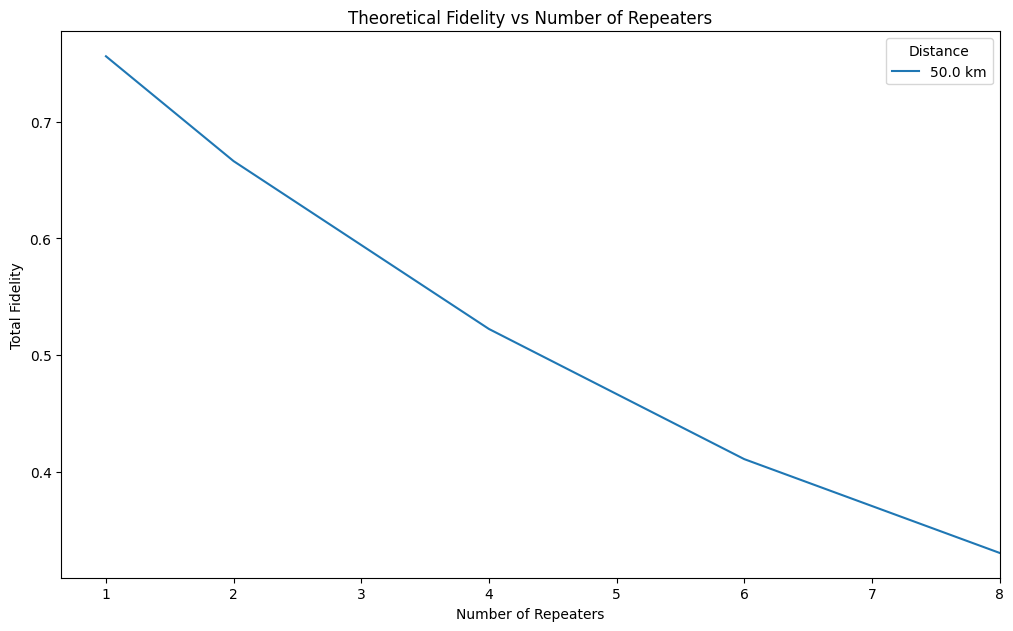

In [1]:
from qnpack.oneG.theo_fid import TheoFidSimulation
fixed_params = {
    "ion_trap": {"coherence_time": 60000000},
}

varying_params = {
    "num_repeaters": [1, 2, 4, 6, 8],
    "distances": [50],
}

sim = TheoFidSimulation(fixed_params=fixed_params, varying_params=varying_params,
                        parameter_file="parameters/noisy.yml",
                        output_dir="results")
data = sim.start()
sim.plot(final_data=data, x_axis1="num_repeaters", y_axis1="fidelity",  xlabel1="Number of Repeaters", ylabel1="Theoretical Fidelity",
         label_param1="Distance", title1="Fidelity vs Number of Repeaters")

### Comparison with real simulation

20:47:47 qnpack.oneG.iontrap INFO Running simulation with parameters: {'num_repeaters': [1, 2, 4, 6, 8], 'distance': [50]}
20:47:47 qnpack.oneG.iontrap INFO Fixed parameters: {'photon_loss': 0.2, 'init_photon_loss': 0.7, 'coherence_time': 60000000}
20:47:47 qnpack.oneG.iontrap INFO Iterations: 10
20:47:47 qnpack.oneG.iontrap INFO Running simulation with parameters: {'num_repeaters': 1, 'distance': 50}
20:47:52 qnpack.oneG.lib.protocols WARNING CP: BSM detection was not successful within 90 retries for node_bsm2
20:47:53 qnpack.oneG.lib.protocols WARNING CP: BSM detection was not successful within 90 retries for node_bsm1
20:47:55 qnpack.oneG.lib.protocols WARNING CP: BSM detection was not successful within 90 retries for node_bsm1
20:47:56 qnpack.oneG.lib.protocols WARNING CP: BSM detection was not successful within 90 retries for node_bsm2
20:47:57 qnpack.oneG.lib.protocols WARNING CP: BSM detection was not successful within 90 retries for node_bsm2
20:47:59 qnpack.oneG.iontrap INFO 	

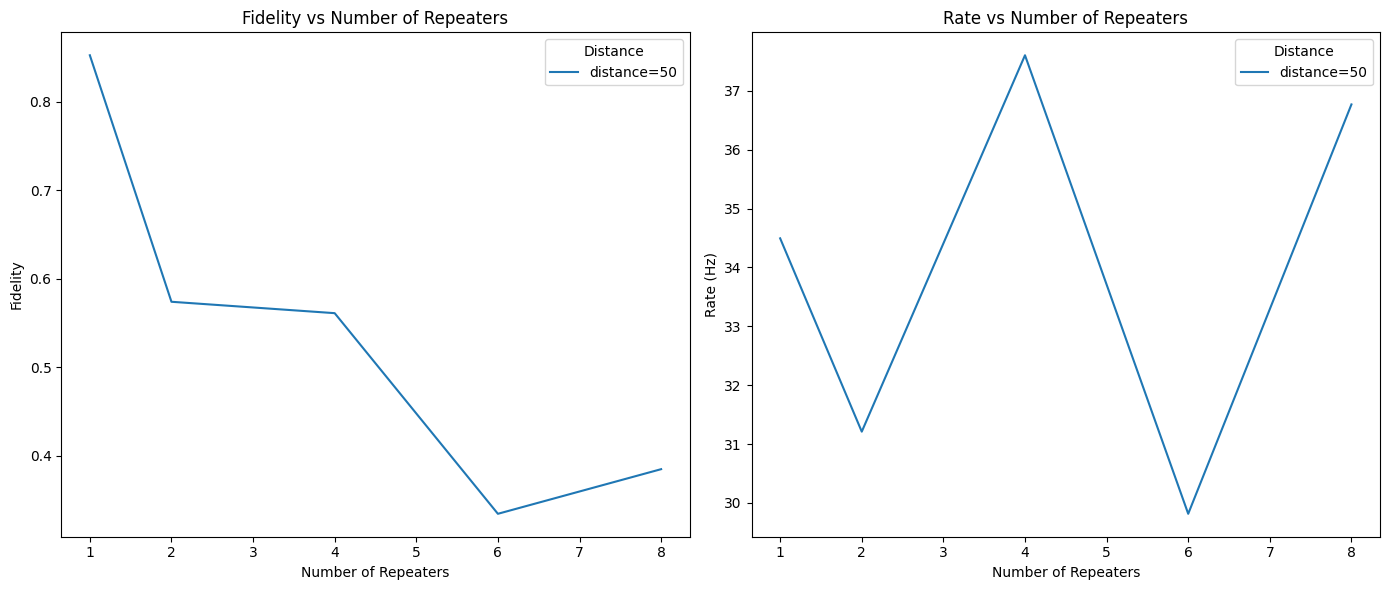

In [2]:
from qnpack.oneG.iontrap import IonTrapSimulation
fixed_params = {
    "photon_loss": 0.2,
    "init_photon_loss": 0.7,
    "coherence_time": 60000000, #ns
}

varying_params = {
    "num_repeaters": [1, 2, 4, 6, 8],
    "distance": [50],
}

sim = IonTrapSimulation(fixed_params=fixed_params, varying_params=varying_params,
                        iterations=10,
                        parameter_file="parameters/noisy.yml",
                        output_dir="results")
data = sim.start()
sim.plot(final_data=data, x_axis1="num_repeaters", y_axis1="fidelity",  xlabel1="Number of Repeaters", ylabel1="Fidelity",
         label_param1="distance", title1="Fidelity vs Number of Repeaters",
         x_axis2="num_repeaters", y_axis2="rate",  xlabel2="Number of Repeaters", ylabel2="Rate (Hz)",
         label_param2="distance", title2="Rate vs Number of Repeaters")